In [ ]:
from trainer_tools.all import Trainer, configure_logging
from trainer_tools.hooks import BatchTransformHook, ProgressBarHook, MetricsHook, LRSchedulerHook, AMPHook, GradClipHook, CheckpointHook
from trainer_tools.hooks.metrics import Loss, Accuracy, SamplesPerSecond
from trainer_tools.imports import *
from graph_attention.all import *

In [ ]:
configure_logging()

<RootLogger root (INFO)>

In [ ]:
BS = 64
variant = 'imagenette'

ds = get_dataset(variant, root="../data", train=True)
valid_ds = get_dataset(variant, root="../data", train=False)
# in notebook persistent_workers=False will cause some weird error messages about child processes
train_dl = DataLoader(ds, batch_size=BS, shuffle=True, num_workers=4, persistent_workers=True)
valid_dl = DataLoader(valid_ds, batch_size=BS, shuffle=False, num_workers=4, persistent_workers=True)
batch_x_transforms = get_batch_transforms(variant)
batch_x_transforms_valid = get_batch_transforms(variant, train=False)

In [ ]:
batch_x_transforms, batch_x_transforms_valid

(Compose(
       Compose(    RandomHorizontalFlip(p=0.5))
       ToDtype(scale=True)
       Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225], inplace=False)
 ),
 Compose(
       ToDtype(scale=True)
       Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225], inplace=False)
 ))

In [ ]:
EPOCHS = 10 #30
LR = 5e-4
WEIGHT_DECAY = 0.005
WARMUP_STEPS = 500
GRAD_CLIP_MAX_NORM = 2.0
AMP_ENABLED = True
CHECKPOINT_EVERY = 1000
SAVE_DIR = "../checkpoints/vit_cifar10"

model = SimpleViT(
    image_size=224,
    patch_size=16,
    num_classes=len(ds.classes),
    dim=192,
    depth=12,
    num_heads=6,
    mlp_ratio=4,
    attention_layer=partial(AGFAttention, top_k=16, order=5)
)

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

In [ ]:
loss_func = torch.nn.CrossEntropyLoss()

total_steps = len(train_dl) * EPOCHS


scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=LR,
    total_steps=len(train_dl) * EPOCHS,
    pct_start=0.1,
    anneal_strategy="cos",
    div_factor=10.0,
    final_div_factor=100.0,
)

hooks = [
    ProgressBarHook(),
    BatchTransformHook(x_tfm=batch_x_transforms, x_tfms_valid=batch_x_transforms_valid), 
    MetricsHook(metrics=[Loss(), Accuracy(), SamplesPerSecond()], verbose=True, tracker_type='trackio', project='graph-attention'),
    LRSchedulerHook(scheduler),
    AMPHook(enabled=AMP_ENABLED, dtype=torch.bfloat16),
    GradClipHook(max_norm=GRAD_CLIP_MAX_NORM),
    CheckpointHook(save_dir=SAVE_DIR, save_every_steps=CHECKPOINT_EVERY, keep_last=3),
]

trainer = Trainer(
    model=model, train_dl=train_dl, valid_dl=valid_dl, optim=optimizer, loss_func=loss_func, epochs=EPOCHS, hooks=hooks
)

In [ ]:
trainer.fit()

* Trackio project initialized: graph-attention
* Trackio metrics logged to: /home/slakter/.cache/huggingface/trackio
* View dashboard by running in your terminal:
trackio show --project "graph-attention"
* or by running in Python: trackio.show(project="graph-attention")
* Created new run: eager-mountain-3
20:41:19 [INFO] trainer_tools.hooks.optimization: Mixed Precision Training: Enabled


Epoch:   0%|          | 0/10 [00:00<?, ?it/s]

Epoch 1/10 [Train]:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 1/10 [Valid]:   0%|          | 0/62 [00:00<?, ?it/s]

20:41:49 [INFO] trainer_tools.hooks.metrics.metrics_hook: Epoch 1/10 | samples_per_second: 420.1771 | train_accuracy: 0.3372 | train_loss: 1.9119 | valid_accuracy: 0.4674 | valid_loss: 1.5994


...

Epoch 9/10 [Valid]:   0%|          | 0/62 [00:00<?, ?it/s]

20:45:47 [INFO] trainer_tools.hooks.metrics.metrics_hook: Epoch 9/10 | samples_per_second: 407.0393 | train_accuracy: 0.6502 | train_loss: 1.0750 | valid_accuracy: 0.6987 | valid_loss: 0.9379


Epoch 10/10 [Train]:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 10/10 [Valid]:   0%|          | 0/62 [00:00<?, ?it/s]

20:46:16 [INFO] trainer_tools.hooks.metrics.metrics_hook: Epoch 10/10 | samples_per_second: 409.7053 | train_accuracy: 0.6543 | train_loss: 1.0661 | valid_accuracy: 0.7045 | valid_loss: 0.9292
* Run finished. Uploading logs to Trackio (please wait...)
20:46:16 [INFO] trainer_tools.hooks.checkpoint: Saved checkpoint: ../checkpoints/vit_cifar10/model_final.pt
20:46:16 [INFO] trainer_tools.checkpoint: Saved model to ../checkpoints/vit_cifar10/model.pt


In [ ]:
trainer.get_hook(MetricsHook).plot(metrics = ["loss", "accuracy", "samples_per_second"], show_epochs=True)

In [ ]:
xb, yb = next(iter(valid_dl))
xb = batch_x_transforms_valid(xb)

In [ ]:
random_model = SimpleViT(
    image_size=224,
    patch_size=16,
    num_classes=len(ds.classes),
    dim=192,
    depth=12,
    num_heads=3,
    mlp_ratio=4,
    attention_layer=partial(AGFAttention, top_k=64, order=5)
)
with torch.no_grad():
    res = random_model(xb)
    res = model(xb.cuda())

In [ ]:
model.backbone.blocks[-1].attn.alphas

tensor([[0.4757, 0.4762, 0.4777, 0.4731, 0.4757, 0.4753],
        [0.4882, 0.4838, 0.4860, 0.4833, 0.4884, 0.4894],
        [0.4840, 0.4834, 0.4851, 0.4799, 0.4923, 0.4857],
        [0.4869, 0.4836, 0.4856, 0.4829, 0.4934, 0.4880],
        [0.4849, 0.4836, 0.4853, 0.4810, 0.4938, 0.4862],
        [0.4869, 0.4839, 0.4853, 0.4826, 0.4941, 0.4879]], device='cuda:0',
       grad_fn=<SigmoidBackward0>)

In [ ]:
random_model.backbone.blocks[-1].attn.alphas

tensor([[0.5000, 0.5000, 0.5000],
        [0.5000, 0.5000, 0.5000],
        [0.5000, 0.5000, 0.5000],
        [0.5000, 0.5000, 0.5000],
        [0.5000, 0.5000, 0.5000],
        [0.5000, 0.5000, 0.5000]], grad_fn=<SigmoidBackward0>)

In [ ]:
last_attn = model.backbone.blocks[-1].attn.last_adj

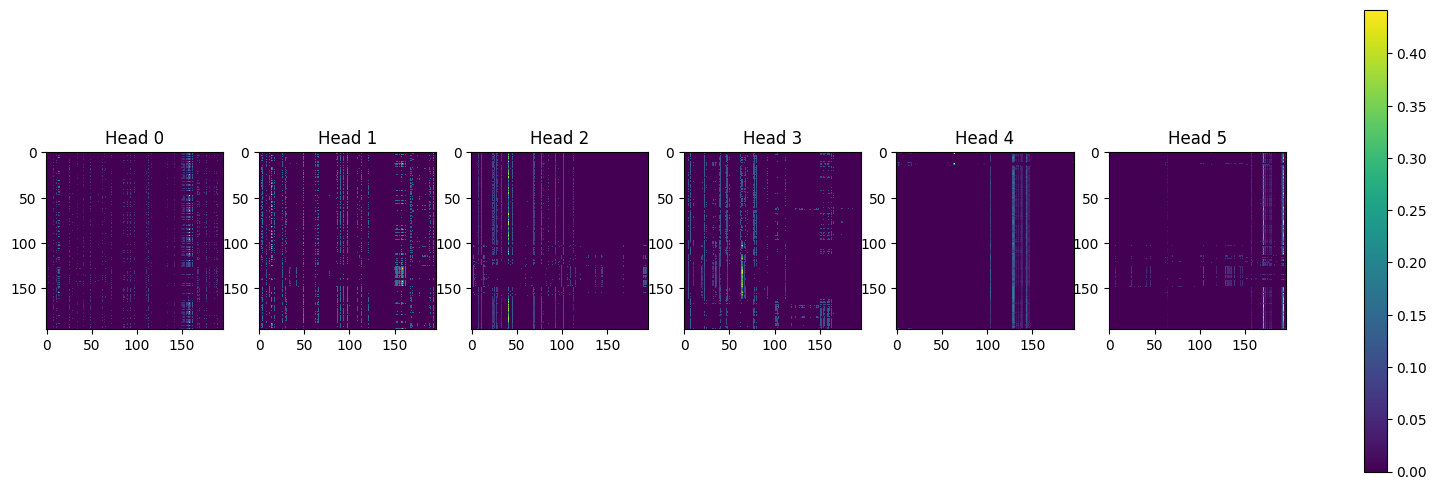

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, model.backbone.num_heads, figsize=(20, 12))

for i in range(model.backbone.num_heads):
    im = axes[i].imshow(last_attn[0, i].cpu(), interpolation='nearest')
    axes[i].set_title(f"Head {i}")

fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.5)

plt.show()

In [ ]:
import torch
import torch.nn.functional as F

def get_similarity_matrix(attn_matrix, basis="monomial", max_pow=10):
    if attn_matrix.dim() > 2:
        attn_matrix = attn_matrix[0, 0]
    
    N = attn_matrix.size(0)
    basis_vectors = []
    
    # We simulate the forward loop logic
    v_curr = torch.eye(N, device=attn_matrix.device) # Using Identity as 'V' to see matrix structure
    v_prev = None
    
    for i in range(max_pow):
        a_v = attn_matrix @ v_curr
        
        if basis == "monomial":
            v_curr = a_v
            term_to_measure = v_curr
            
        elif basis == "residual":
            # Basis is the difference: (A^k - A^{k-1})
            term_to_measure = a_v - v_curr
            v_curr = a_v
            
        elif basis == "chebyshev":
            # T_n basis logic
            shifted_a_v = 2 * a_v - v_curr
            if i == 0:
                v_next = v_curr
            elif i == 1:
                v_next = shifted_a_v
            else:
                v_next = 2 * shifted_a_v - v_prev
            
            v_prev, v_curr = v_curr, v_next
            term_to_measure = v_curr

        basis_vectors.append(term_to_measure.reshape(-1))

    # Calculate Cosine Similarity Matrix
    stacked = torch.stack(basis_vectors)
    norm = stacked.norm(dim=1, keepdim=True)
    normalized = stacked / (norm + 1e-8)
    sim_mat = torch.mm(normalized, normalized.t())
    
    return sim_mat.cpu().detach().numpy()

In [ ]:
block = 2
attn = model.backbone.blocks[block].attn.last_adj[0, 0]
attn_rand = random_model.backbone.blocks[block].attn.last_adj[0, 0]

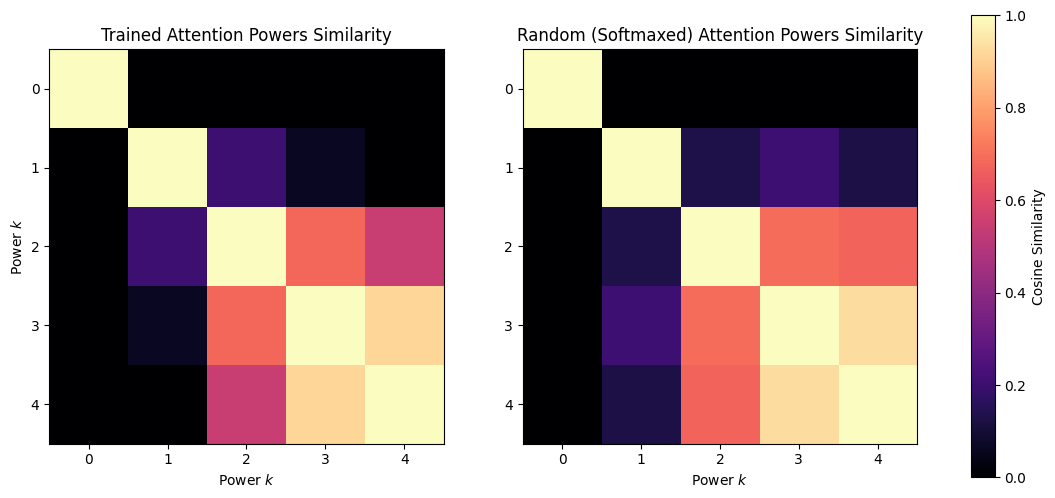

In [ ]:
max_p = 5

sim_real = get_similarity_matrix(attn, "residual", max_p)
sim_rand = get_similarity_matrix(attn_rand, "residual", max_p)

# 3. Plotting
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

im1 = ax1.imshow(sim_real, cmap="magma", vmin=0, vmax=1)
ax1.set_title("Trained Attention Powers Similarity")
ax1.set_xlabel("Power $k$")
ax1.set_ylabel("Power $k$")

im2 = ax2.imshow(sim_rand, cmap="magma", vmin=0, vmax=1)
ax2.set_title("Random (Softmaxed) Attention Powers Similarity")
ax2.set_xlabel("Power $k$")

# Add a shared colorbar
fig.colorbar(im1, ax=[ax1, ax2], label="Cosine Similarity")

plt.show()

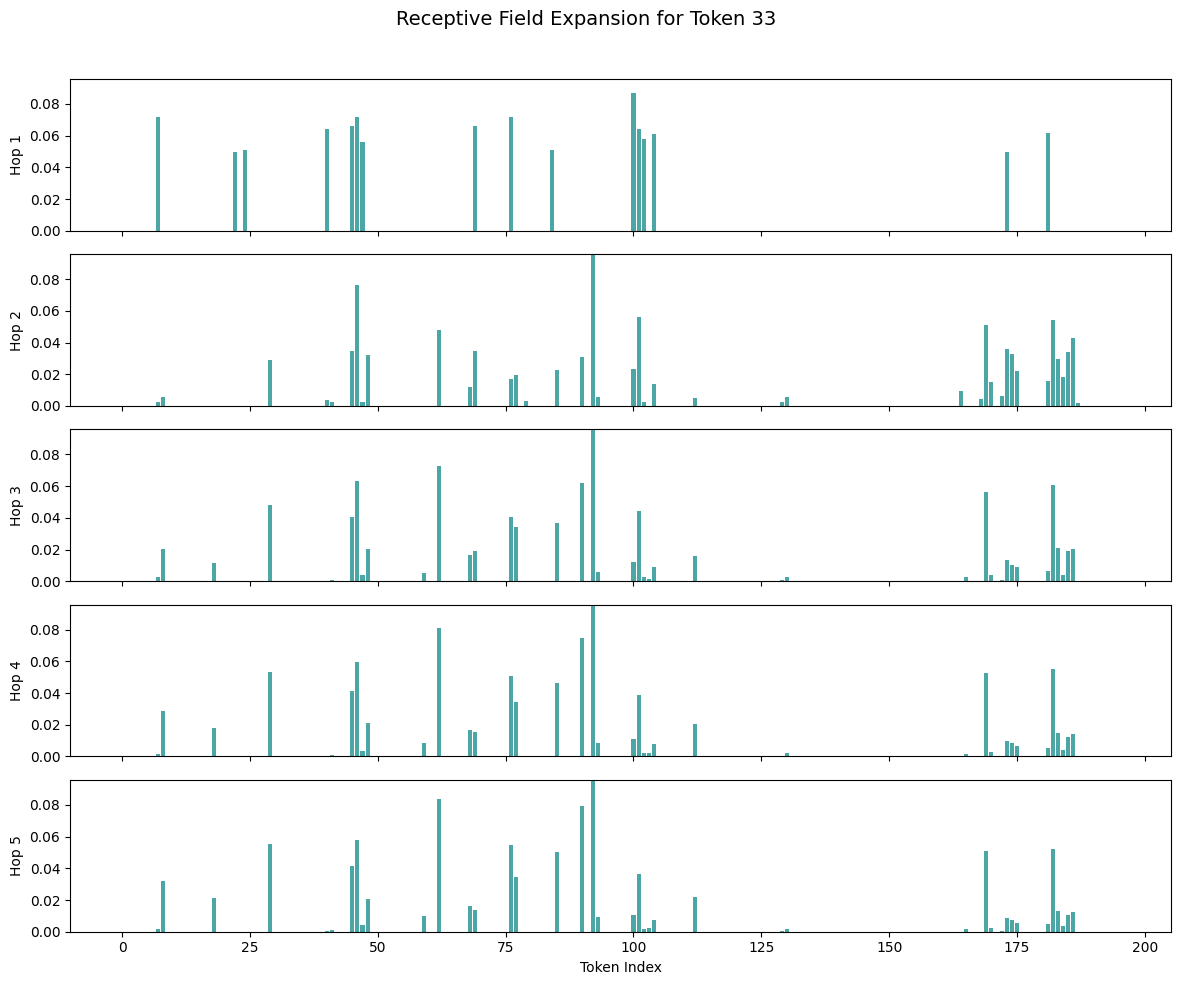

In [ ]:
import torch
import matplotlib.pyplot as plt

def plot_receptive_field(attn_matrix, source_token_idx=50, max_hops=5):
    """
    Visualizes how the 'spotlight' of attention spreads from a single token
    across multiple hops.
    """
    if attn_matrix.dim() > 2:
        attn_matrix = attn_matrix[0, 0] # Pick first batch, first head
    
    N = attn_matrix.size(0)
    hops = []
    current_power = torch.eye(N, device=attn_matrix.device)
    
    for i in range(max_hops):
        current_power = current_power @ attn_matrix
        # Extract the row for our source token
        influence = current_power[source_token_idx].cpu().detach().numpy()
        hops.append(influence)
    
    # Plotting
    fig, axes = plt.subplots(max_hops, 1, figsize=(12, 2 * max_hops), sharex=True)
    fig.suptitle(f"Receptive Field Expansion for Token {source_token_idx}", fontsize=14)
    
    for k in range(max_hops):
        axes[k].bar(range(N), hops[k], color='teal', alpha=0.7)
        axes[k].set_ylabel(f"Hop {k+1}")
        axes[k].set_ylim(0, max(hops[0]) * 1.1) # Scale to first hop for comparison
        
    plt.xlabel("Token Index")
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

# Run it on your trained matrix
plot_receptive_field(attn, source_token_idx=33) # Middle of your 190 seq